<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [10]</a>'.</span>

# C5G7 Infinite Pincell Array

In [1]:
# Change start method form 'fork' for clusters
import multiprocessing
multiprocessing.set_start_method('forkserver')

import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad

from ttnte.xs.benchmarks import c5g7
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, eig
from ttnte.cad import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 1024

# Get XS data
xs_server = c5g7()

In [3]:
# Create quarter circle NURBS surface
radius = 0.54 # cm
pitch = 1.26 # cm
c0 = cad.circle(radius=radius, angle=np.pi / 2)
c1 = c0.slice(0, 0, 0.5)
c2 = c0.slice(0, 0.5, 1)
l0 = cad.line(p0=(0, 0), p1=(0, 0))

# Create water patch
l1 = cad.line(p0=(pitch / 2, 0), p1=(pitch / 2, pitch / 2))
l2 = cad.line(p0=(pitch / 2, pitch / 2), p1=(0, pitch / 2))

# Create NURBS surfaces
fuel = [Patch(cad.ruled(l0, c1), "UO2"), Patch(cad.ruled(l0, c2), "UO2")]
water = [Patch(cad.ruled(c1, l1), "Water"), Patch(cad.ruled(c2, l2), "Water")]

# Initialize IGA mesh and add the patches
mesh = IGAMesh()
for patch in fuel + water:
    mesh.add_patch(patch)

# Refine each patch to have 6 knot spans with degree 2
mesh.refine(6, 2)

# Connect patches
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_conditions(("left", "bottom", "top", "right"))

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=4, reflective_boundaries=True)
  -> Patch(material=UO2, source=None, id=0, name=None, shape=(8, 8), backend=geomdl)
  -> Patch(material=UO2, source=None, id=1, name=None, shape=(8, 8), backend=geomdl)
  -> Patch(material=Water, source=None, id=2, name=None, shape=(8, 8), backend=geomdl)
  -> Patch(material=Water, source=None, id=3, name=None, shape=(8, 8), backend=geomdl)

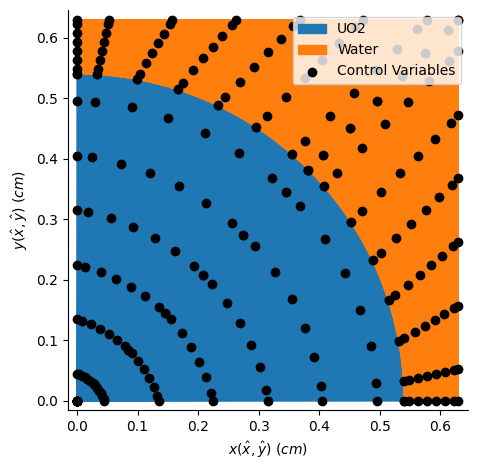

In [4]:
# Plot final mesh
ax = mesh.plot()
plt.tight_layout()
plt.savefig("./figs/pincell.png", dpi=300)
plt.show()

## Assemble Matrix and TT Operators

In [5]:
# Create operators in COO format
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
mats = assembler.build()

# Save COO information
assembler.save_info("./coo_info.csv")

# Create operators in TT format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
    max_processes=2,
)
tts = assembler.build(use_tt=False, eps=1e-10)

# Save TT information
assembler.save_info("./tt_info.csv")

Running MatrixAssembler.build()
Discretization: N = 1024, G = 7, P = 4, A = 8, B = 8
Operators: H, S, F, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/4 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 19.16 s)
Step            Ranks                     Compression
H               1835008,1835008             33864.05
S               1,1792,1792                     7.09
F               1792,1792                      16.54
B_out           1835008,1835008            654955.07
B_in            1835008,1835008            647316.38
Running TTAssembler.build()
Discretization: N = 1024, G = 7, P = 4, A = 8, B = 8
Operators: H, S, F, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/4 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 6.53 s)
Step            Ranks                     Compression
H               3,3,3,4,12,34             98170681.05
S               1,1,1,2,4,22              432031608.94
F               1,1,1,1,2,18              828352856.10
B_out           4,28,41,41,42,8           7407706.25
B_in            8,32,43,43,43,9           5976147.55


## Solve

In [6]:
# COO operators only
k, psi = eig(
    LHS=LinearOperator(
        [mats.H + mats.B_out - mats.B_in, -mats.S], 
        N=assembler.N, 
        M=assembler.M
    ),
    RHS=LinearOperator([mats.F], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
    linear_solver_opts={
        "max_iterations": 50,
        "threshold": 1e-10,
        "resets": 15,
    },
)

Starting power iteration


-- (0): k = 0.59876164, Angular Flux L2-Error = 1.6813926, Elapsed Time = 11.26


-- (1): k = 0.77920732, Angular Flux L2-Error = 0.42612461, Elapsed Time = 22.358


-- (2): k = 1.05262351, Angular Flux L2-Error = 0.14359764, Elapsed Time = 33.46


-- (3): k = 1.20625848, Angular Flux L2-Error = 0.05516219, Elapsed Time = 44.562


...

-- (66): k = 1.32536333, Angular Flux L2-Error = 2e-08, Elapsed Time = 743.513


-- (67): k = 1.32536333, Angular Flux L2-Error = 2e-08, Elapsed Time = 754.606


-- (68): k = 1.32536333, Angular Flux L2-Error = 1e-08, Elapsed Time = 765.699


-- (69): k = 1.32536333, Angular Flux L2-Error = 1e-08, Elapsed Time = 776.793


-- (70): k = 1.32536333, Angular Flux L2-Error = 1e-08, Elapsed Time = 787.887
-- Converged: k = 1.32536333, Elapsed Time = 787.888


In [7]:
# TT operators only
k, psi = eig(
    LHS=LinearOperator(
        [tts.H, tts.B_out, -tts.B_in, -tts.S], 
        N=assembler.N, 
        M=assembler.M
    ),
    RHS=LinearOperator([mats.F], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
    linear_solver_opts={
        "max_iterations": 100,
        "threshold": 1e-10,
        "resets": 10,
    },
)

Starting power iteration


-- (0): k = 0.61432963, Angular Flux L2-Error = 2.11640125, Elapsed Time = 304.837


-- (1): k = 1.01442095, Angular Flux L2-Error = 0.32056263, Elapsed Time = 609.308


-- (2): k = 1.22393231, Angular Flux L2-Error = 0.07663754, Elapsed Time = 913.793


-- (3): k = 1.29486604, Angular Flux L2-Error = 0.02146831, Elapsed Time = 1218.259


...

-- (50): k = 1.32536333, Angular Flux L2-Error = 2e-08, Elapsed Time = 15528.9


-- (51): k = 1.32536333, Angular Flux L2-Error = 2e-08, Elapsed Time = 15833.348


-- (52): k = 1.32536333, Angular Flux L2-Error = 1e-08, Elapsed Time = 16137.807


-- (53): k = 1.32536333, Angular Flux L2-Error = 1e-08, Elapsed Time = 16442.263


-- (54): k = 1.32536333, Angular Flux L2-Error = 1e-08, Elapsed Time = 16746.725
-- Converged: k = 1.32536333, Elapsed Time = 16746.726


In [8]:
# Use both COO and TT operators
k, psi = eig(
    LHS=LinearOperator(
        [tts.H, mats.B_out - mats.B_in, -tts.S], 
        N=assembler.N, 
        M=assembler.M
    ),
    RHS=LinearOperator([tts.F], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
    linear_solver_opts={
        "max_iterations": 100,
        "threshold": 1e-10,
        "resets": 10,
    },
)

# Save solution
mesh.save(path="mesh.hdf5", solution=psi, k=k)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

Starting power iteration


-- (0): k = 0.61432963, Angular Flux L2-Error = 2.11640125, Elapsed Time = 37.291


-- (1): k = 1.01442095, Angular Flux L2-Error = 0.32056263, Elapsed Time = 74.614


-- (2): k = 1.22393231, Angular Flux L2-Error = 0.07663754, Elapsed Time = 111.947


-- (3): k = 1.29486604, Angular Flux L2-Error = 0.02146831, Elapsed Time = 149.27


...

-- (50): k = 1.32536333, Angular Flux L2-Error = 2e-08, Elapsed Time = 1903.8


-- (51): k = 1.32536333, Angular Flux L2-Error = 2e-08, Elapsed Time = 1941.126


-- (52): k = 1.32536333, Angular Flux L2-Error = 1e-08, Elapsed Time = 1978.46


-- (53): k = 1.32536333, Angular Flux L2-Error = 1e-08, Elapsed Time = 2015.785


-- (54): k = 1.32536333, Angular Flux L2-Error = 1e-08, Elapsed Time = 2053.119
-- Converged: k = 1.32536333, Elapsed Time = 2053.12


## Plotting and Comparison to OpenMC

In [9]:
# Get OpenMC solution
k_mc = [1.325593, 0.000032]
phi_mc = np.load("./openmc/data/mesh_flux.npy")

# Ensure OpenMC solution is normalized
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

# Calculate eigenvalue error
print("keff error: {} +/- {} pcm".format((k - k_mc[0]) * 1e5, k_mc[1]))

keff error: -22.966984505834454 +/- 3.2e-05 pcm


<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [10]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(5, 5))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax, cbar = mesh.plot(plot_ctrlpts=False)
    cbar.set_label(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}.png", dpi=300)
    plt.show()

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/home/myerspat/anaconda3/envs/tt_nte/lib/python3.11/multiprocessing/forkserver.py", line 258, in main
    fds = reduction.recvfds(s, MAXFDS_TO_SEND + 1)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/myerspat/anaconda3/envs/tt_nte/lib/python3.11/multiprocessing/reduction.py", line 159, in recvfds
    raise EOFError
EOFError


OSError: [Errno 24] Too many open files

In [ ]:
# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

# Regular mesh
X, Y = np.meshgrid(
    np.linspace(0, pitch / 2, phi_mc.shape[1]),
    np.linspace(0, pitch / 2, phi_mc.shape[2]),
)

for g in range(xs_server.num_groups):    
    # Plot relative error
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(
        X, Y, (phi_mc[g,] - phi_avg[g,]) / phi_mc[g,], cmap="plasma"
    )
    divider = make_axes_locatable(ax)

    plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
        label=f"Relative Scalar Flux Error ($g = {g + 1}$)",
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi{g + 1}_error.png", dpi=300)
    plt.show()
    
    # Calculate groups L2-error
    print(
        "Scalar flux Relative L2-error (g = {}): {}".format(
            g + 1, 
            np.linalg.norm(
                (phi_avg[g,] - phi_mc[g,]).flatten(), 2
            ) / np.linalg.norm(phi_mc[g,].flatten(), 2)
        )
    )
print(
    "Total scalar flux Relative L2-error: {}".format(
        np.linalg.norm(
            (phi_avg - phi_mc).flatten(), 2
        ) / np.linalg.norm(phi_mc.flatten(), 2)
    )
)